In [ ]:
import shutil
import pathlib
import os
src = pathlib.Path("/kaggle/input/datasets/ckay16/accident-detection-from-cctv-footage/data")
dst = pathlib.Path("/kaggle/working/data")

if not dst.exists():
    shutil.copytree(src, dst)
    print("Copied!")
else:
    print("Already exists")

# Now point data_dir to the writable copy
data_dir = pathlib.Path("/kaggle/working/data")






Already exists



--- Cleaning train/ ---
Done — 0 corrupt files removed

--- Cleaning val/ ---
Done — 0 corrupt files removed

--- Cleaning test/ ---
Done — 0 corrupt files removed
train: {'Accident': 369, 'Non Accident': 409}


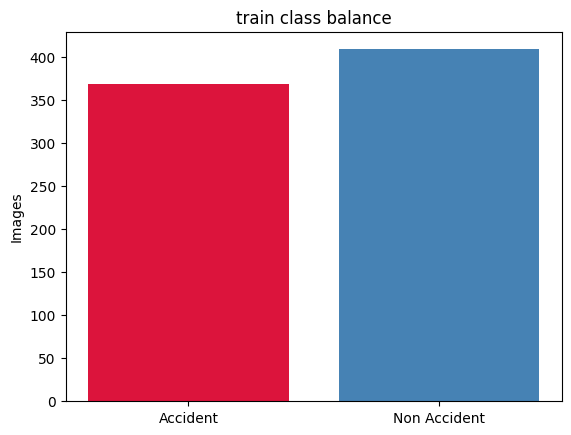

val: {'Accident': 46, 'Non Accident': 45}


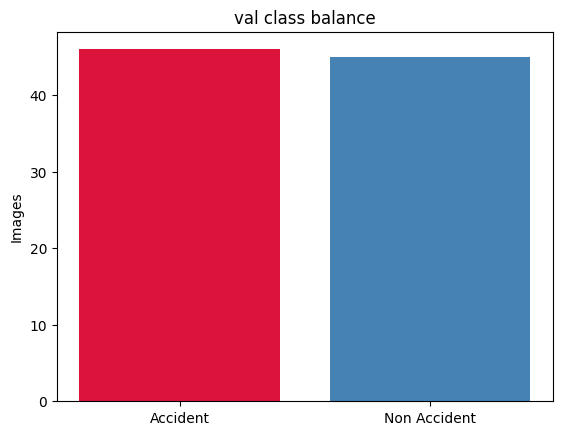

test: {'Accident': 47, 'Non Accident': 49}


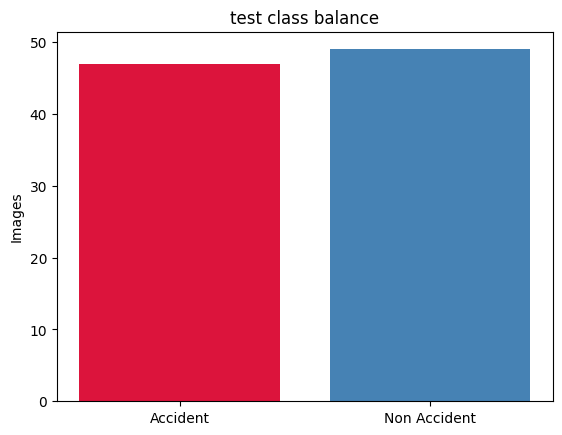

In [119]:
from PIL import Image
import hashlib
import matplotlib.pyplot as plt

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

for split in ["train", "val", "test"]:
    split_dir = data_dir / split   
    
    if not split_dir.exists():
        print(f"Skipping {split}/ — folder not found")
        continue

    print(f"\n--- Cleaning {split}/ ---")

    for f in split_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() not in VALID_EXT:
            print(f"Removing invalid: {f.name}")
            os.remove(f)

    corrupt = []
    for img_path in split_dir.rglob("*.*"):
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupt.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupt: {img_path.name}")

    print(f"Done — {len(corrupt)} corrupt files removed")

# Duplicates + balance
seen = {}
for split in ["train", "val", "test"]:
    for f in (data_dir / split).rglob("*.*"):
        h = hashlib.md5(f.read_bytes()).hexdigest()
        if h in seen:
            print(f"Duplicate removed: {f.name}")
            os.remove(f)
        else:
            seen[h] = f.name

for split in ["train", "val", "test"]:
    counts = {f.name: len(list(f.rglob("*.*")))
              for f in (data_dir / split).iterdir() if f.is_dir()}
    print(f"{split}: {counts}")
    plt.bar(counts.keys(), counts.values(), color=['crimson', 'steelblue'])
    plt.title(f"{split} class balance")
    plt.ylabel("Images")
    plt.show()

In [120]:
import os
# Suppress TensorFlow logging (0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# Suppress additional internal absl warnings
import logging
tf.get_logger().setLevel(logging.ERROR)

In [121]:
# ----------------------------
# Configuration
# ----------------------------
DATA_DIR = data_dir
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 50
FINE_TUNE_EPOCHS = 50

# ----------------------------
# Data Pipeline
# ----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

class_names = train_ds.class_names  # ['Accident', 'Non Accident']
print(f"Detected classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE




Found 778 files belonging to 2 classes.
Found 91 files belonging to 2 classes.
Found 96 files belonging to 2 classes.
Detected classes: ['Accident', 'Non Accident']


In [122]:
# Cache + prefetch for performance. Cache before augmentation since
# augmentation must remain stochastic across epochs.

train_ds = (
    train_ds
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------
# Class Imbalance Handling
# ----------------------------
train_labels = np.concatenate([y.numpy() for _, y in train_ds.unbatch()])
neg, pos = np.bincount(train_labels.astype(int).flatten())
total = neg + pos
class_weight = {0: total / (2 * neg), 1: total / (2 * pos)}
print(f"Computed class weights: {class_weight}")

# ----------------------------
# Data Augmentation (training only)
# ----------------------------
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(
          height_factor=0.1, # Shift up/down by up to 10%
          width_factor=0.1   # Shift left/right by up to 10%
        ),
    ],
    name="data_augmentation"
)

# ----------------------------
# Model Construction
# ----------------------------
# EfficientNetV2S has built-in preprocessing (expects raw [0,255] pixel
# values), so no manual Rescaling layer is needed before the backbone.
base_model = applications.MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
    pooling=None
)
base_model.trainable = False  # Freeze pre-trained weights

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512 , activation = "relu" )(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128 , activation = "relu" )(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs, name="accident_classifier")

Computed class weights: {0: np.float64(1.0542005420054201), 1: np.float64(0.9511002444987775)}


In [123]:
# ----------------------------
# Compilation
# ----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

model.summary()

# ----------------------------
# Callbacks
# ----------------------------
os.makedirs("models", exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
        min_delta=1e-4 # Added early stopping minimum delta parameter
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="models/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]




Model: "accident_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_52 (InputLayer)     │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 10, 10, 960)    │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_17     │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 512)            │       492,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,554,177 (13.56 MB)

 Trainable params: 557,825 (2.13 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [124]:
# ----------------------------
# Training
# ----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

# ----------------------------
# Fine-Tuning
# ----------------------------
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the top 50
fine_tune_at = len(base_model.layers) - 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile the model with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(
        
    ),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

# Continue training for a few more epochs
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=len(history.epoch), 
    callbacks=callbacks,
    class_weight=class_weight
)



Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4863 - loss: 0.8545 - precision: 0.5210 - recall: 0.5286
Epoch 1: val_loss improved from None to 0.64556, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step - accuracy: 0.4846 - loss: 0.8473 - precision: 0.5099 - recall: 0.5061 - val_accuracy: 0.6154 - val_loss: 0.6456 - val_precision: 0.7273 - val_recall: 0.3556 - learning_rate: 1.0000e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5346 - loss: 0.7733 - precision: 0.5599 - recall: 0.5041
Epoch 2: val_loss improved from 0.64556 to 0.61434, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.5540 - loss: 0.7354 - precision: 0.5871 - recall: 0.5110 - val_accuracy: 0.6593 - val_loss: 0.6143 - val_precision: 0.7500 - val_recall: 0.4667 - learning_rate: 1.0000e-04
Ep

In [125]:
model.save("Rawane_wassim.keras")